
# Assignment 1: Query Clustering for Intent Discovery in Web Search

This notebook is the primary submission workflow. It is self-contained and covers:

- multilingual preprocessing and translation-based normalization
- query representations using word TF-IDF, character n-gram TF-IDF, and dense embeddings
- clustering with K-means, Agglomerative Hierarchical Clustering, and DBSCAN
- hyperparameter comparison, stability analysis, and clustering evaluation
- cluster labeling, frequent pattern extraction, visualizations, and final export files



## Setup

The notebook writes the final submission artifacts to `../results/`:

- `final_query_clusters.csv`
- `cluster_summary.md`
- `report.md`
- figures in `../results/figures/`


In [8]:

from __future__ import annotations

import math
import re
import unicodedata
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
np.set_printoptions(suppress=True)

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'data' / 'queries.csv').exists() else CWD.parent
DATA_PATH = ROOT / 'data' / 'queries.csv'
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2'
DOMAIN_STOP_WORDS = sorted(ENGLISH_STOP_WORDS.union({
    'goa', 'best', 'cheap', 'top', 'today', 'tomorrow', 'next', 'week', 'now', 'direct'
}))

DEVANAGARI_PATTERN = re.compile(r'[ऀ-ॿ]')
TAMIL_PATTERN = re.compile(r'[஀-௿]')
MULTISPACE_PATTERN = re.compile(r'\s+')

TRANSLATION_MAP = {
    'गोवा': 'goa',
    'मौसम': 'weather',
    'तापमान': 'temperature',
    'होटल': 'hotel',
    'पर्यटन': 'tourism',
    'यात्रा': 'travel',
    'बीच': 'beach',
    'बुकING': 'booking',
    'बुकिंग': 'booking',
    'आज': 'today',
    'ट्रैवल': 'travel',
    'फ्लाइट': 'flight',
    'கோவா': 'goa',
    'வானிலை': 'weather',
    'ஹோட்டல்': 'hotel',
    'சுற்றுலா': 'tourism',
    'விமானம்': 'flight',
    'பயணம்': 'travel',
}

CANONICAL_MAP = {
    'hotels': 'hotel',
    'resorts': 'resort',
    'restaurants': 'restaurant',
    'cafes': 'cafe',
    'beaches': 'beach',
    'flights': 'flight',
    'tickets': 'ticket',
    'airfare': 'flight',
    'airline': 'flight',
    'airport': 'flight',
    'rent': 'rental',
    'rental': 'rental',
    'vehicles': 'vehicle',
    'deals': 'deal',
    'packages': 'package',
    'holidays': 'holiday',
    'vacation': 'holiday',
    'honeymoon': 'honeymoon',
    'tour': 'travel',
    'tours': 'travel',
    'tourist': 'travel',
    'tourism': 'travel',
    'trip': 'travel',
    'travel': 'travel',
    'guide': 'guide',
    'itinerary': 'itinerary',
    'sightseeing': 'sightseeing',
    'attractions': 'attraction',
    'booking': 'booking',
    'cab': 'taxi',
    'car': 'car',
    'bike': 'bike',
    'scooter': 'scooter',
    'taxi': 'taxi',
    'hire': 'rental',
}

INTENT_KEYWORDS = {
    'weather': {'weather', 'temperature', 'rain', 'rainy', 'humidity', 'climate', 'monsoon'},
    'hotel': {'hotel', 'resort', 'booking'},
    'restaurant': {'restaurant', 'food', 'cafe', 'dinner', 'seafood', 'vegetarian'},
    'tourism': {'travel', 'guide', 'sightseeing', 'beach', 'nightlife', 'itinerary', 'attraction', 'tip', 'blog', 'visit'},
    'flight': {'flight', 'ticket', 'airport'},
    'transport': {'car', 'bike', 'scooter', 'taxi', 'rental', 'transport', 'vehicle', 'drive'},
    'package': {'package', 'holiday', 'honeymoon', 'deal'},
}


Task was destroyed but it is pending!
task: <Task pending name='Task-100' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-101' coro=<Kernel.shell_main() running at /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/collections/__init__.py:450: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @classmethod
Task was destroyed but it is pending!
task: <Task pending name='Task-101' coro=<Kernel.shell_main() running at /Users/krithika/Desktop/BITS/Sem 2/IR/Assignme

In [9]:

def load_queries(path: Path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['query'] = df['query'].fillna('').astype(str).str.strip()
    df = df[df['query'] != ''].reset_index(drop=True)
    df.insert(0, 'query_id', range(len(df)))
    return df


def detect_language(query: str) -> str:
    if DEVANAGARI_PATTERN.search(query):
        return 'hindi'
    if TAMIL_PATTERN.search(query):
        return 'tamil'
    return 'english'


def normalize_unicode(text: str) -> str:
    return unicodedata.normalize('NFKC', text)


def strip_punctuation(text: str) -> str:
    return ''.join(char if not unicodedata.category(char).startswith('P') else ' ' for char in text)


def tokenize(text: str) -> list[str]:
    return text.split()


def translate_tokens(tokens: list[str]) -> list[str]:
    return [TRANSLATION_MAP.get(token, token) for token in tokens]


def canonicalize_tokens(tokens: list[str]) -> list[str]:
    return [CANONICAL_MAP.get(token, token) for token in tokens]


def normalize_query(query: str) -> str:
    text = normalize_unicode(query).lower().strip()
    text = strip_punctuation(text)
    return MULTISPACE_PATTERN.sub(' ', text).strip()


def build_cross_lingual_query(query: str) -> str:
    translated = translate_tokens(tokenize(normalize_unicode(query).lower().strip()))
    canonical = canonicalize_tokens(translated)
    return normalize_query(' '.join(canonical))


def assign_intent_tag(query: str) -> str:
    tokens = set(tokenize(query))
    if tokens & INTENT_KEYWORDS['weather']:
        return 'weather'
    if tokens & INTENT_KEYWORDS['package']:
        return 'package'
    if tokens & INTENT_KEYWORDS['hotel']:
        return 'hotel'
    if tokens & INTENT_KEYWORDS['restaurant']:
        return 'restaurant'
    if tokens & INTENT_KEYWORDS['flight']:
        return 'flight'
    if tokens & INTENT_KEYWORDS['transport']:
        return 'transport'
    if tokens & INTENT_KEYWORDS['tourism']:
        return 'tourism'
    return 'other'


def preprocess_queries(df: pd.DataFrame) -> pd.DataFrame:
    processed = df.copy()
    processed['language'] = processed['query'].map(detect_language)
    processed['normalized_query'] = processed['query'].map(normalize_query)
    processed['cross_lingual_query'] = processed['query'].map(build_cross_lingual_query)
    processed['intent_tag'] = processed['cross_lingual_query'].map(assign_intent_tag)
    processed['is_multilingual'] = processed['language'].ne('english')
    return processed


queries_df = preprocess_queries(load_queries())
queries_df.head(10)


,query_id,query,language,normalized_query,cross_lingual_query,intent_tag,is_multilingual
0,0,weather goa,english,weather goa,weather goa,weather,False
1,1,temperature in goa,english,temperature in goa,temperature in goa,weather,False
2,2,goa weather today,english,goa weather today,goa weather today,weather,False
3,3,goa weather forecast,english,goa weather forecast,goa weather forecast,weather,False
4,4,weather in goa tomorrow,english,weather in goa tomorrow,weather in goa tomorrow,weather,False
5,5,rain forecast goa,english,rain forecast goa,rain forecast goa,weather,False
6,6,goa humidity today,english,goa humidity today,goa humidity today,weather,False
7,7,goa temperature now,english,goa temperature now,goa temperature now,weather,False
8,8,goa weather next week,english,goa weather next week,goa weather next week,weather,False
9,9,weather update goa,english,weather update goa,weather update goa,weather,False


In [10]:
queries_df[['query', 'language', 'cross_lingual_query', 'intent_tag']].tail(15)

,query,language,cross_lingual_query,intent_tag
80,गोवा मौसम,hindi,goa weather,weather
81,गोवा तापमान,hindi,goa temperature,weather
82,गोवा होटल,hindi,goa hotel,hotel
83,गोवा पर्यटन,hindi,goa travel,tourism
84,गोवा यात्रा,hindi,goa travel,tourism
85,गोवा बीच,hindi,goa beach,tourism
86,गोवा होटल बुकिंग,hindi,goa hotel booking,hotel
87,गोवा मौसम आज,hindi,goa weather today,weather
88,गोवा ट्रैवल,hindi,goa travel,tourism
89,गोवा फ्लाइट,hindi,goa flight,flight


## Query Representations

In [11]:

def tfidf_vectors(queries: list[str], *, analyzer: str, ngram_range: tuple[int, int]) -> tuple[np.ndarray, TfidfVectorizer]:
    vectorizer = TfidfVectorizer(
        analyzer=analyzer,
        ngram_range=ngram_range,
        stop_words=DOMAIN_STOP_WORDS if analyzer == 'word' else None,
        sublinear_tf=True,
    )
    matrix = vectorizer.fit_transform(queries)
    return normalize(matrix).toarray(), vectorizer


def embedding_vectors(queries: list[str]) -> tuple[np.ndarray, object, str]:
    try:
        model = SentenceTransformer(EMBEDDING_MODEL_NAME, local_files_only=True)
        vectors = model.encode(queries, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)
        return vectors, model, 'sentence_transformer'
    except Exception:
        vectorizer = TfidfVectorizer(stop_words=DOMAIN_STOP_WORDS, ngram_range=(1, 2), sublinear_tf=True)
        matrix = vectorizer.fit_transform(queries)
        n_components = min(50, max(2, matrix.shape[0] - 1), matrix.shape[1] - 1)
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        vectors = normalize(svd.fit_transform(matrix))
        return vectors, (vectorizer, svd), 'lsa_fallback'


representation_map = {}
word_vectors, word_vectorizer = tfidf_vectors(queries_df['cross_lingual_query'].tolist(), analyzer='word', ngram_range=(1, 2))
char_vectors, char_vectorizer = tfidf_vectors(queries_df['cross_lingual_query'].tolist(), analyzer='char_wb', ngram_range=(3, 5))
embed_vectors, embed_model, embed_backend = embedding_vectors(queries_df['cross_lingual_query'].tolist())
representation_map['tfidf_word'] = {'vectors': word_vectors, 'backend': 'tfidf_word', 'vectorizer': word_vectorizer, 'feature_count': word_vectors.shape[1]}
representation_map['tfidf_char'] = {'vectors': char_vectors, 'backend': 'tfidf_char', 'vectorizer': char_vectorizer, 'feature_count': char_vectors.shape[1]}
representation_map['embedding'] = {'vectors': embed_vectors, 'backend': embed_backend, 'vectorizer': embed_model, 'feature_count': embed_vectors.shape[1]}

pd.DataFrame([
    {'representation': name, 'backend': meta['backend'], 'feature_count': meta['feature_count']}
    for name, meta in representation_map.items()
])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,representation,backend,feature_count
0,tfidf_word,tfidf_word,116
1,tfidf_char,tfidf_char,1008
2,embedding,sentence_transformer,384


## Clustering and Evaluation

In [12]:

def default_specs() -> list[dict[str, object]]:
    specs = []
    for n_clusters in range(6, 11):
        specs.append({'algorithm': 'kmeans', 'params': {'n_clusters': n_clusters}})
        specs.append({'algorithm': 'agglomerative', 'params': {'n_clusters': n_clusters, 'metric': 'cosine', 'linkage': 'average'}})
    for eps in (0.25, 0.3, 0.35, 0.4, 0.45):
        for min_samples in (2, 3, 4):
            specs.append({'algorithm': 'dbscan', 'params': {'eps': eps, 'min_samples': min_samples, 'metric': 'cosine'}})
    return specs


def fit_predict(spec: dict[str, object], vectors: np.ndarray) -> tuple[np.ndarray, object]:
    algorithm = spec['algorithm']
    params = dict(spec['params'])
    if algorithm == 'kmeans':
        model = KMeans(n_clusters=params['n_clusters'], random_state=42, n_init='auto')
    elif algorithm == 'agglomerative':
        model = AgglomerativeClustering(n_clusters=params['n_clusters'], metric=params['metric'], linkage=params['linkage'])
    elif algorithm == 'dbscan':
        model = DBSCAN(eps=params['eps'], min_samples=params['min_samples'], metric=params['metric'])
    else:
        raise ValueError(algorithm)
    labels = model.fit_predict(vectors)
    return np.asarray(labels), model


def cluster_purity(labels: np.ndarray, intent_tags: list[str]) -> float:
    scores = []
    for cluster_id in sorted(set(labels.tolist())):
        if cluster_id == -1:
            continue
        intents = [intent for label, intent in zip(labels, intent_tags) if label == cluster_id]
        if intents:
            counts = Counter(intents)
            scores.append(max(counts.values()) / len(intents))
    return float(np.mean(scores)) if scores else float('nan')


def cluster_size_stats(labels: np.ndarray) -> tuple[float, float, float]:
    valid = labels[labels != -1]
    if len(valid) == 0:
        return 0.0, 0.0, 1.0
    counts = Counter(valid.tolist())
    largest_share = max(counts.values()) / len(labels)
    mean_size = float(np.mean(list(counts.values())))
    tiny_ratio = sum(size for size in counts.values() if size < 4) / len(labels)
    return largest_share, mean_size, tiny_ratio


def evaluate_clusters(vectors: np.ndarray, labels: np.ndarray, intent_tags: list[str]) -> dict[str, float]:
    mask = labels != -1
    valid_vectors = vectors[mask]
    valid_labels = labels[mask]
    largest_cluster_share, mean_cluster_size, tiny_cluster_ratio = cluster_size_stats(labels)
    metrics = {
        'cluster_count': float(len(set(valid_labels.tolist()))) if len(valid_labels) else 0.0,
        'noise_points': float(np.sum(labels == -1)),
        'noise_ratio': float(np.mean(labels == -1)),
        'assigned_ratio': float(np.mean(labels != -1)),
        'largest_cluster_share': largest_cluster_share,
        'mean_cluster_size': mean_cluster_size,
        'tiny_cluster_ratio': tiny_cluster_ratio,
        'silhouette': float('nan'),
        'davies_bouldin': float('nan'),
        'calinski_harabasz': float('nan'),
        'cluster_purity': cluster_purity(labels, intent_tags),
    }
    if len(valid_labels) >= 3 and len(set(valid_labels.tolist())) >= 2:
        metrics['silhouette'] = float(silhouette_score(valid_vectors, valid_labels, metric='cosine'))
        metrics['davies_bouldin'] = float(davies_bouldin_score(valid_vectors, valid_labels))
        metrics['calinski_harabasz'] = float(calinski_harabasz_score(valid_vectors, valid_labels))
    return metrics


def estimate_stability(vectors: np.ndarray, fit_predict_subset, *, runs: int = 6, sample_ratio: float = 0.85) -> float:
    rng = np.random.default_rng(42)
    sample_size = max(3, int(round(len(vectors) * sample_ratio)))
    samples = []
    for _ in range(runs):
        indices = np.sort(rng.choice(len(vectors), size=sample_size, replace=False))
        labels = np.asarray(fit_predict_subset(vectors[indices]))
        samples.append((indices, labels))
    scores = []
    for (idx_a, labels_a), (idx_b, labels_b) in combinations(samples, 2):
        common, pos_a, pos_b = np.intersect1d(idx_a, idx_b, return_indices=True)
        if len(common) < 3:
            continue
        la = labels_a[pos_a]
        lb = labels_b[pos_b]
        if len(set(la.tolist())) < 2 or len(set(lb.tolist())) < 2:
            continue
        scores.append(adjusted_rand_score(la, lb))
    return float(np.mean(scores)) if scores else float('nan')


def top_neighbors(similarities: np.ndarray, candidate_indices, exclude_index: int, k: int) -> list[int]:
    ranked = [(idx, similarities[idx]) for idx in candidate_indices if idx != exclude_index]
    ranked.sort(key=lambda item: item[1], reverse=True)
    return [idx for idx, _ in ranked[:k]]


def precision_at_k(intent_tags: list[str], query_index: int, neighbors: list[int]) -> float:
    if not neighbors:
        return 0.0
    target = intent_tags[query_index]
    return float(sum(intent_tags[idx] == target for idx in neighbors) / len(neighbors))


def evaluate_suggestions(vectors: np.ndarray, labels: np.ndarray, intent_tags: list[str], k: int = 3) -> dict[str, float]:
    similarities = cosine_similarity(vectors)
    baseline_scores = []
    cluster_scores = []
    coverage = 0
    for idx in range(len(vectors)):
        baseline_neighbors = top_neighbors(similarities[idx], range(len(vectors)), idx, k)
        baseline_scores.append(precision_at_k(intent_tags, idx, baseline_neighbors))
        cluster_candidates = [j for j, label in enumerate(labels) if label == labels[idx] and j != idx and label != -1]
        if cluster_candidates:
            coverage += 1
            cluster_neighbors = top_neighbors(similarities[idx], cluster_candidates, idx, min(k, len(cluster_candidates)))
            cluster_scores.append(precision_at_k(intent_tags, idx, cluster_neighbors))
        else:
            cluster_scores.append(baseline_scores[-1])
    return {
        'baseline_precision_at_3': float(np.mean(baseline_scores)),
        'cluster_precision_at_3': float(np.mean(cluster_scores)),
        'suggestion_lift': float(np.mean(cluster_scores) - np.mean(baseline_scores)),
        'cluster_suggestion_coverage': float(coverage / len(vectors)),
    }


def selection_score(row: dict[str, float]) -> float:
    silhouette = 0.0 if pd.isna(row['silhouette']) else row['silhouette']
    stability = 0.0 if pd.isna(row['stability']) else row['stability']
    score = (
        (1.15 * silhouette)
        + (0.30 * stability)
        + (0.35 * row['cluster_purity'])
        + (0.35 * row['assigned_ratio'])
        + (0.20 * row['suggestion_lift'])
        - (0.55 * row['noise_ratio'])
        - (0.30 * row['tiny_cluster_ratio'])
        - (0.35 * max(row['largest_cluster_share'] - 0.25, 0.0))
        - (0.12 * (abs(row['cluster_count'] - 8.0) / 8.0))
    )
    if row['assigned_ratio'] < 0.85:
        score -= 3.0
    return score


def format_params(params: dict[str, object]) -> str:
    return ', '.join(f'{key}={value}' for key, value in params.items())


In [13]:

intent_tags = queries_df['intent_tag'].tolist()
experiment_rows = []

for representation_name, representation in representation_map.items():
    vectors = representation['vectors']
    for spec in default_specs():
        labels, _ = fit_predict(spec, vectors)
        metrics = evaluate_clusters(vectors, labels, intent_tags)
        suggestion_metrics = evaluate_suggestions(vectors, labels, intent_tags)
        stability = estimate_stability(vectors, lambda subset, spec=spec: fit_predict(spec, subset)[0])
        row = {
            'representation': representation_name,
            'representation_backend': representation['backend'],
            'feature_count': representation['feature_count'],
            'algorithm': spec['algorithm'],
            'param_summary': format_params(spec['params']),
            'stability': stability,
            **metrics,
            **suggestion_metrics,
        }
        row['selection_score'] = selection_score(row)
        experiment_rows.append(row)

experiments_df = pd.DataFrame(experiment_rows).sort_values('selection_score', ascending=False).reset_index(drop=True)
best_row = experiments_df.iloc[0].to_dict()
best_suggestion_row = (
    experiments_df[experiments_df['assigned_ratio'] >= 0.85]
    .sort_values(['suggestion_lift', 'cluster_purity', 'silhouette', 'stability'], ascending=False)
    .iloc[0]
    .to_dict()
)

experiments_df.head(12)


,representation,representation_backend,feature_count,algorithm,param_summary,stability,cluster_count,noise_points,noise_ratio,assigned_ratio,...,tiny_cluster_ratio,silhouette,davies_bouldin,calinski_harabasz,cluster_purity,baseline_precision_at_3,cluster_precision_at_3,suggestion_lift,cluster_suggestion_coverage,selection_score
0,embedding,sentence_transformer,384,kmeans,n_clusters=8,0.765976,8.0,0.0,0.0,1.0,...,0.010526,0.357672,1.462577,11.408097,0.837066,0.866667,0.863158,-0.003509,0.989474,1.280229
1,embedding,sentence_transformer,384,agglomerative,"n_clusters=8, metric=cosine, linkage=average",0.992439,8.0,0.0,0.0,1.0,...,0.042105,0.318250,1.367299,9.222228,0.863562,0.866667,0.873684,0.007018,0.978947,1.266975
2,embedding,sentence_transformer,384,agglomerative,"n_clusters=10, metric=cosine, linkage=average",0.885911,10.0,0.0,0.0,1.0,...,0.052632,0.328872,1.249230,8.844508,0.905958,0.866667,0.870175,0.003509,0.968421,1.257684
3,embedding,sentence_transformer,384,agglomerative,"n_clusters=9, metric=cosine, linkage=average",0.974313,9.0,0.0,0.0,1.0,...,0.052632,0.310100,1.275060,8.372055,0.883442,0.866667,0.870175,0.003509,0.968421,1.240263
4,embedding,sentence_transformer,384,kmeans,n_clusters=10,0.742653,10.0,0.0,0.0,1.0,...,0.010526,0.315104,1.562949,10.878259,0.899798,0.866667,0.863158,-0.003509,0.989474,1.216235
5,embedding,sentence_transformer,384,kmeans,n_clusters=7,0.715737,7.0,0.0,0.0,1.0,...,0.010526,0.318199,1.698360,10.935183,0.882086,0.866667,0.852632,-0.014035,0.989474,1.202757
6,embedding,sentence_transformer,384,kmeans,n_clusters=9,0.768488,9.0,0.0,0.0,1.0,...,0.010526,0.288179,1.674669,10.590815,0.855170,0.866667,0.863158,-0.003509,0.989474,1.192402
7,embedding,sentence_transformer,384,agglomerative,"n_clusters=7, metric=cosine, linkage=average",0.886099,7.0,0.0,0.0,1.0,...,0.042105,0.289919,1.391299,8.857404,0.807223,0.866667,0.863158,-0.003509,0.978947,1.165669
8,embedding,sentence_transformer,384,kmeans,n_clusters=6,0.590146,6.0,0.0,0.0,1.0,...,0.000000,0.321934,1.874638,12.558891,0.847282,0.866667,0.852632,-0.014035,1.000000,1.145352
9,embedding,sentence_transformer,384,agglomerative,"n_clusters=6, metric=cosine, linkage=average",0.887272,6.0,0.0,0.0,1.0,...,0.021053,0.282193,1.472429,9.909880,0.782038,0.866667,0.863158,-0.003509,0.978947,1.139636


## Best Overall Configuration and Best Suggestion Configuration

In [14]:
pd.DataFrame([best_row, best_suggestion_row])[['representation', 'representation_backend', 'algorithm', 'param_summary', 'silhouette', 'cluster_purity', 'stability', 'suggestion_lift', 'assigned_ratio', 'selection_score']]

,representation,representation_backend,algorithm,param_summary,silhouette,cluster_purity,stability,suggestion_lift,assigned_ratio,selection_score
0,embedding,sentence_transformer,kmeans,n_clusters=8,0.357672,0.837066,0.765976,-0.003509,1.0,1.280229
1,tfidf_char,tfidf_char,agglomerative,"n_clusters=10, metric=cosine, linkage=average",0.267248,0.880252,0.765927,0.049123,1.0,1.127789


## Cluster Summaries for the Best Overall Configuration

In [15]:

def representative_scores(vectors: np.ndarray, labels: np.ndarray) -> np.ndarray:
    scores = np.zeros(len(labels))
    similarities = cosine_similarity(vectors)
    for cluster_id in sorted(set(labels.tolist())):
        members = np.where(labels == cluster_id)[0]
        if len(members) == 0:
            continue
        if len(members) == 1:
            scores[members[0]] = 1.0
            continue
        scores[members] = similarities[np.ix_(members, members)].mean(axis=1)
    return scores


def extract_patterns(queries: list[str], top_k: int = 5) -> list[str]:
    vectorizer = CountVectorizer(stop_words=DOMAIN_STOP_WORDS, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(queries)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top_indices = counts.argsort()[::-1][:top_k]
    return [terms[index] for index in top_indices if counts[index] > 0]


def summarize_clusters(assignments: pd.DataFrame) -> pd.DataFrame:
    clustered = assignments[assignments['cluster_id'] != -1].copy().reset_index(drop=True)
    if clustered.empty:
        return pd.DataFrame(columns=['cluster_id', 'label', 'top_terms', 'top_patterns', 'intent_mix', 'representative_queries', 'size'])
    vectorizer = TfidfVectorizer(stop_words=DOMAIN_STOP_WORDS, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(clustered['cross_lingual_query'])
    terms = np.array(vectorizer.get_feature_names_out())
    rows = []
    for cluster_id in sorted(clustered['cluster_id'].unique()):
        cluster_rows = clustered[clustered['cluster_id'] == cluster_id]
        cluster_matrix = matrix[cluster_rows.index.to_numpy()]
        mean_scores = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        top_indices = mean_scores.argsort()[::-1][:5]
        top_terms = [terms[index] for index in top_indices if mean_scores[index] > 0]
        label = ' / '.join(top_terms[:2]) if top_terms else f'cluster {cluster_id}'
        intent_mix = ', '.join(f'{intent}={count}' for intent, count in Counter(cluster_rows['intent_tag']).most_common())
        representative_queries = cluster_rows.sort_values('representative_score', ascending=False).head(3)['query'].tolist()
        rows.append({
            'cluster_id': int(cluster_id),
            'label': label,
            'top_terms': ', '.join(top_terms),
            'top_patterns': ', '.join(extract_patterns(cluster_rows['cross_lingual_query'].tolist())),
            'intent_mix': intent_mix,
            'representative_queries': ' | '.join(representative_queries),
            'size': int(len(cluster_rows)),
        })
    return pd.DataFrame(rows)


def params_from_summary(summary: str) -> dict[str, object]:
    params = {}
    for item in summary.split(', '):
        key, value = item.split('=', 1)
        if value.replace('.', '', 1).isdigit():
            params[key] = float(value) if '.' in value else int(value)
        else:
            params[key] = value
    return params

best_spec = {'algorithm': best_row['algorithm'], 'params': params_from_summary(best_row['param_summary'])}
best_vectors = representation_map[best_row['representation']]['vectors']
best_labels, _ = fit_predict(best_spec, best_vectors)
assignments_df = queries_df.copy()
assignments_df['representation'] = best_row['representation']
assignments_df['cluster_id'] = best_labels
assignments_df['representative_score'] = representative_scores(best_vectors, best_labels)
cluster_summary_df = summarize_clusters(assignments_df)
final_df = assignments_df.merge(cluster_summary_df[['cluster_id', 'label', 'top_terms', 'top_patterns']], on='cluster_id', how='left')

cluster_summary_df[['cluster_id', 'label', 'size', 'intent_mix', 'representative_queries']]


,cluster_id,label,size,intent_mix,representative_queries
0,0,nightlife,1,tourism=1,goa nightlife
1,1,flight / flight booking,12,"flight=10, package=1, hotel=1",flights to goa | गोवा फ्लाइट | கோவா விமானம்
2,2,weather / temperature,23,weather=23,கோவா வானிலை | गोवा मौसम | weather goa
3,3,travel / package,23,"tourism=13, package=8, other=1, transport=1",goa tourism | गोवा पर्यटन | கோவா சுற்றுலா
4,4,restaurant / food,10,restaurant=10,restaurants in goa | goa food places | goa dinner places
5,5,rental / car,9,"transport=8, hotel=1",goa rental vehicles | goa car hire | car rental goa
6,6,beach / resort,6,"hotel=3, tourism=2, package=1",goa beach resorts | गोवा बीच | best beaches in goa
7,7,hotel / hotel booking,11,"hotel=10, package=1",गोवा होटल | கோவா ஹோட்டல் | luxury hotels goa


## Visualizations

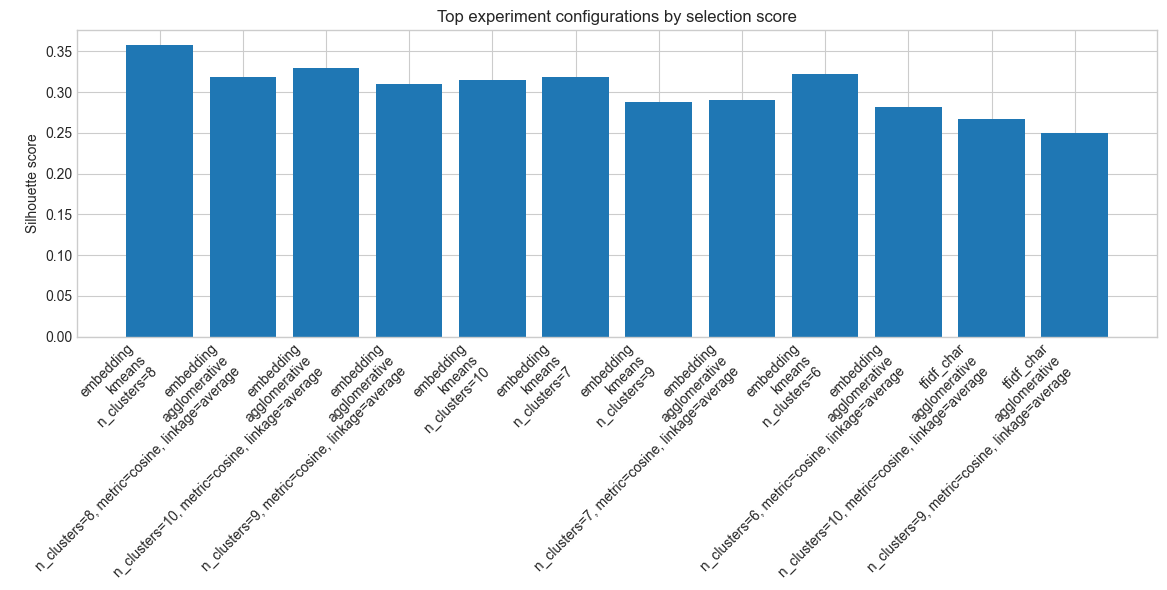

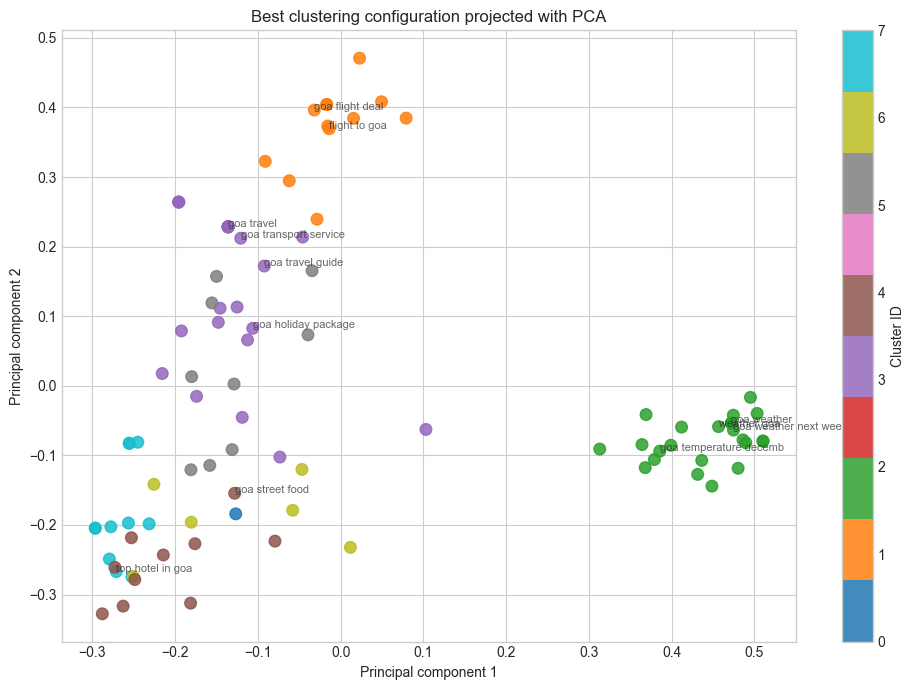

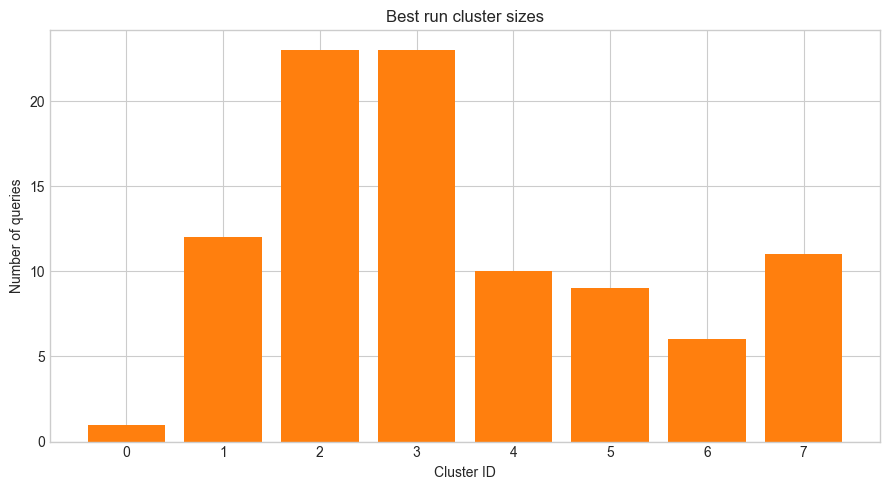

In [16]:

def plot_experiment_scores(results: pd.DataFrame, output_path: Path) -> None:
    top_runs = results.head(12).copy()
    labels = top_runs.apply(lambda row: f"{row['representation']}\n{row['algorithm']}\n{row['param_summary']}", axis=1)
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(top_runs)), top_runs['silhouette'].fillna(0.0), color='#1f77b4')
    plt.xticks(range(len(top_runs)), labels, rotation=45, ha='right')
    plt.ylabel('Silhouette score')
    plt.title('Top experiment configurations by selection score')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    plt.close()


def plot_best_clusters(vectors: np.ndarray, labels: np.ndarray, queries: list[str], output_path: Path) -> None:
    projection = PCA(n_components=2, random_state=42).fit_transform(vectors)
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(projection[:, 0], projection[:, 1], c=labels, cmap='tab10', s=70, alpha=0.85)
    for idx, query in enumerate(queries):
        if idx % 8 == 0:
            plt.annotate(query[:22], (projection[idx, 0], projection[idx, 1]), fontsize=8, alpha=0.7)
    plt.colorbar(scatter, label='Cluster ID')
    plt.title('Best clustering configuration projected with PCA')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    plt.close()


def plot_cluster_sizes(cluster_summary: pd.DataFrame, output_path: Path) -> None:
    plt.figure(figsize=(9, 5))
    plt.bar(cluster_summary['cluster_id'].astype(str), cluster_summary['size'], color='#ff7f0e')
    plt.title('Best run cluster sizes')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of queries')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    plt.close()

plot_experiment_scores(experiments_df, FIGURES_DIR / 'experiment_scores.png')
plot_best_clusters(best_vectors, best_labels, queries_df['cross_lingual_query'].tolist(), FIGURES_DIR / 'best_clusters.png')
plot_cluster_sizes(cluster_summary_df, FIGURES_DIR / 'cluster_sizes.png')


## Export Submission Artifacts

In [17]:

def fmt(value: object) -> str:
    if value is None:
        return 'n/a'
    if isinstance(value, float):
        if math.isnan(value):
            return 'n/a'
        return f'{value:.4f}'
    return str(value)


def write_cluster_summary_markdown(cluster_summary: pd.DataFrame, output_path: Path) -> None:
    lines = ['# Cluster Summaries', '']
    for row in cluster_summary.itertuples(index=False):
        lines.append(f'## Cluster {row.cluster_id}: {row.label}')
        lines.append(f'- Size: {row.size}')
        lines.append(f'- Top terms: {row.top_terms}')
        lines.append(f'- Frequent patterns: {row.top_patterns}')
        lines.append(f'- Intent mix: {row.intent_mix}')
        lines.append(f'- Representative queries: {row.representative_queries}')
        lines.append('')
    output_path.write_text('\n'.join(lines), encoding='utf-8')


def write_report_markdown(output_path: Path) -> None:
    best_run_summary = f"{best_row['representation']} [{best_row['representation_backend']}] + {best_row['algorithm']} ({best_row['param_summary']})"
    best_suggestion_summary = f"{best_suggestion_row['representation']} [{best_suggestion_row['representation_backend']}] + {best_suggestion_row['algorithm']} ({best_suggestion_row['param_summary']})"
    lines = [
        '# Assignment 1 Report Draft', '', '## Problem Statement', '',
        'This project clusters web search queries to discover latent user intents and to show how query-side clustering can improve suggestion quality and retrieval grouping.', '',
        '## Dataset', '',
        f"- Total queries: {len(queries_df)}",
        f"- Multilingual queries: {queries_df['is_multilingual'].mean():.1%}",
        '- Domain: Goa travel-related search queries spanning weather, hotels, restaurants, tourism, flights, local transport, packages, and multilingual variants.', '',
        '## Methodology', '',
        '- Preprocessing: Unicode normalization, lowercasing, punctuation cleanup, translation-based normalization for Hindi and Tamil queries, and intent-tag heuristics for downstream evaluation.',
        '- Query representations: word TF-IDF, character n-gram TF-IDF, and a dense embedding representation. The pipeline uses a local sentence-transformer when cached, and otherwise falls back to an offline LSA embedding so the experiment remains reproducible.',
        '- Clustering algorithms: K-means, Agglomerative hierarchical clustering, and DBSCAN.',
        '- Evaluation: silhouette score, Davies-Bouldin index, Calinski-Harabasz score, cluster purity against heuristic intent tags, bootstrap-style stability using adjusted Rand index, and suggestion precision at 3.', '',
        '## Best Configuration', '',
        f'- Best run: {best_run_summary}',
        f"- Silhouette score: {fmt(best_row['silhouette'])}",
        f"- Stability: {fmt(best_row['stability'])}",
        f"- Cluster purity: {fmt(best_row['cluster_purity'])}",
        f"- Suggestion lift over baseline precision@3: {fmt(best_row['suggestion_lift'])}", '',
        '## Cluster Interpretation', '',
    ]
    for row in cluster_summary_df.itertuples(index=False):
        lines.append(f'### Cluster {row.cluster_id}: {row.label}')
        lines.append(f'- Size: {row.size}')
        lines.append(f'- Top terms: {row.top_terms}')
        lines.append(f'- Frequent patterns: {row.top_patterns}')
        lines.append(f'- Intent mix: {row.intent_mix}')
        lines.append(f'- Representative queries: {row.representative_queries}')
        lines.append('')
    lines.extend([
        '## Cross-Lingual Clustering', '',
        'Hindi and Tamil queries are normalized into the same English intent space before vectorization. This translation-based normalization lets multilingual queries join the same clusters as their English counterparts instead of forming isolated script-specific groups.', '',
        '## Query Suggestion Improvement', '',
        f'- Best clustering run for overall balance: {best_run_summary}',
        f'- Best downstream suggestion run: {best_suggestion_summary}',
        f"- Baseline precision@3: {fmt(best_suggestion_row['baseline_precision_at_3'])}",
        f"- Cluster-constrained precision@3: {fmt(best_suggestion_row['cluster_precision_at_3'])}",
        f"- Absolute lift in precision@3: {fmt(best_suggestion_row['suggestion_lift'])}", '',
        '## Assumptions', '',
        '- The provided dataset is a representative sample of Goa travel-related intents.',
        '- Intent tags used in the downstream evaluation are heuristic labels derived from normalized query terms.',
        '- Translation-based normalization is sufficient for the current multilingual subset.', '',
        '## Limitations', '',
        '- The dataset is small and synthetic, so conclusions should be framed as a controlled experiment rather than a production benchmark.',
        '- Heuristic intent tags are useful for analysis, but they are not human-annotated ground truth.', '',
        '## Generated Artifacts', '',
        '- `results/final_query_clusters.csv`', '- `results/cluster_summary.md`', '- `results/report.md`',
        '- `results/figures/experiment_scores.png`', '- `results/figures/best_clusters.png`', '- `results/figures/cluster_sizes.png`', '',
        '## Top Experiment Configurations', '', '```text', experiments_df.head(15).round(4).to_string(index=False), '```', ''
    ])
    output_path.write_text('\n'.join(lines), encoding='utf-8')

final_df.to_csv(RESULTS_DIR / 'final_query_clusters.csv', index=False)
write_cluster_summary_markdown(cluster_summary_df, RESULTS_DIR / 'cluster_summary.md')
write_report_markdown(RESULTS_DIR / 'report.md')

print('Wrote:')
print('-', RESULTS_DIR / 'final_query_clusters.csv')
print('-', RESULTS_DIR / 'cluster_summary.md')
print('-', RESULTS_DIR / 'report.md')
print('-', FIGURES_DIR / 'experiment_scores.png')
print('-', FIGURES_DIR / 'best_clusters.png')
print('-', FIGURES_DIR / 'cluster_sizes.png')


Wrote:
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/final_query_clusters.csv
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/cluster_summary.md
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/report.md
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/figures/experiment_scores.png
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/figures/best_clusters.png
- /Users/krithika/Desktop/BITS/Sem 2/IR/Assignment 1/results/figures/cluster_sizes.png


## Final Submission Table Preview

In [18]:
final_df.head(20)

,query_id,query,language,normalized_query,cross_lingual_query,intent_tag,is_multilingual,representation,cluster_id,representative_score,label,top_terms,top_patterns
0,0,weather goa,english,weather goa,weather goa,weather,False,embedding,2,0.863776,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
1,1,temperature in goa,english,temperature in goa,temperature in goa,weather,False,embedding,2,0.814105,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
2,2,goa weather today,english,goa weather today,goa weather today,weather,False,embedding,2,0.856784,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
3,3,goa weather forecast,english,goa weather forecast,goa weather forecast,weather,False,embedding,2,0.833709,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
4,4,weather in goa tomorrow,english,weather in goa tomorrow,weather in goa tomorrow,weather,False,embedding,2,0.816290,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
5,5,rain forecast goa,english,rain forecast goa,rain forecast goa,weather,False,embedding,2,0.772472,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
6,6,goa humidity today,english,goa humidity today,goa humidity today,weather,False,embedding,2,0.768040,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
7,7,goa temperature now,english,goa temperature now,goa temperature now,weather,False,embedding,2,0.803496,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
8,8,goa weather next week,english,goa weather next week,goa weather next week,weather,False,embedding,2,0.813045,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
9,9,weather update goa,english,weather update goa,weather update goa,weather,False,embedding,2,0.791309,weather / temperature,"weather, temperature, climate, humidity, december","weather, temperature, climate, december, forecast"
